# Logistic Regression, Metrics & Imbalance

**Scaler CML | Applied ML (Intro)**  
**Instructor:** Chitwan Manchanda  
**Session:** 8 (Group B)

Companion notes: `CML8_Notes_Student.md`

This notebook covers intuition → light formulas → sklearn demos → unmarked quizzes.


# 1. Agenda

Topics (in order):
1. Binary classification setup (AT&T churn style motivation)
2. Logistic regression intuition: decision boundary, odds, sigmoid, threshold
3. Light log-loss (why not MSE) + `sklearn.linear_model.LogisticRegression`
4. Confusion matrix, precision, recall, F1
5. ROC curve and AUC
6. Class imbalance: accuracy trap, threshold / operating-point tradeoffs
7. Precision-Recall vs ROC when classes are rare

Work through the concepts, code demos, and unmarked quizzes in order.


# 2. Motivation: binary classification (churn)

Business story: a telco wants to predict whether a customer will **churn** (leave) or **stay**.

- Features $x$: usage minutes, service calls, account length, ...
- Target $y \in \{0, 1\}$: stay vs leave
- This is **supervised binary classification**, not regression onto a real-valued $y$

**Think about it:** Linear regression outputs any real number. How do we get a class (and a probability)?


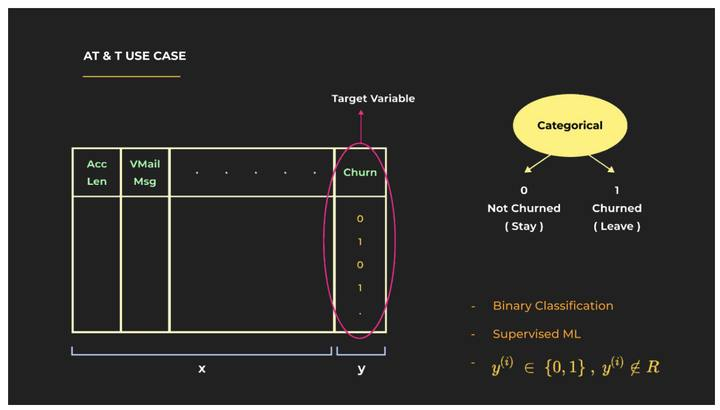


# 3. Best fit vs best separation

Linear regression looks for a **line of best fit** through points.

For two classes in feature space we want a **line (hyperplane) of best separation**: a decision boundary.

- In $d$ features the boundary is a hyperplane in that $d$-dimensional space.
- Points on one side tend toward class 1; the other side toward class 0.


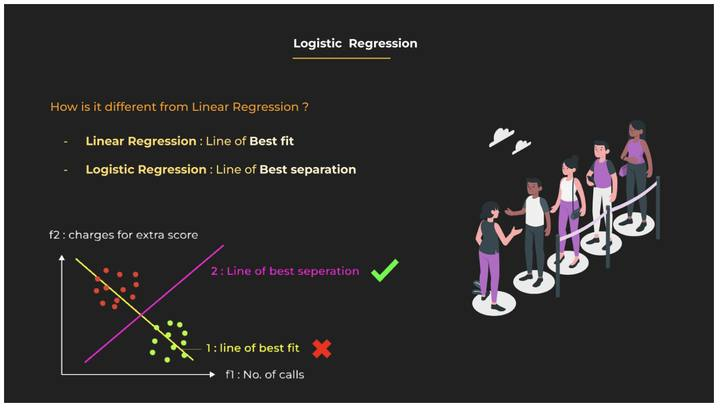


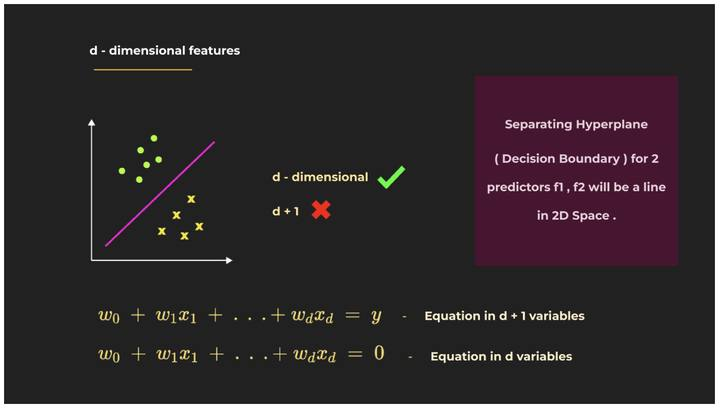


# 4. From linear score to probability: step → sigmoid

Start from a linear score (logit):

$$
z = w^{\top} x + w_0
$$

A hard **step** at threshold $\tau$ maps $z$ to $\{0,1\}$, but the step is **not differentiable**, so gradient-based training is awkward.

Replace the hard step with the **sigmoid** (logistic) function:

$$
\sigma(z) = \frac{1}{1 + e^{-z}} \in (0, 1)
$$

Interpret:

$$
\hat{p} = P(y=1 \mid x) = \sigma(z)
$$

Default rule: predict class 1 if $\hat{p} \ge 0.5$ (equivalent to $z \ge 0$), else class 0. The **threshold is a knob** we can move later.

### Odds (one-liner)

Odds = $p / (1-p)$. Log-odds = $\log(p/(1-p)) = z$. Logistic regression is linear in the **log-odds**.


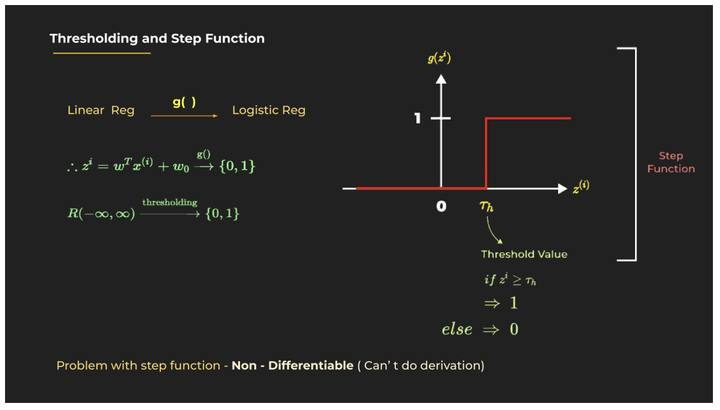


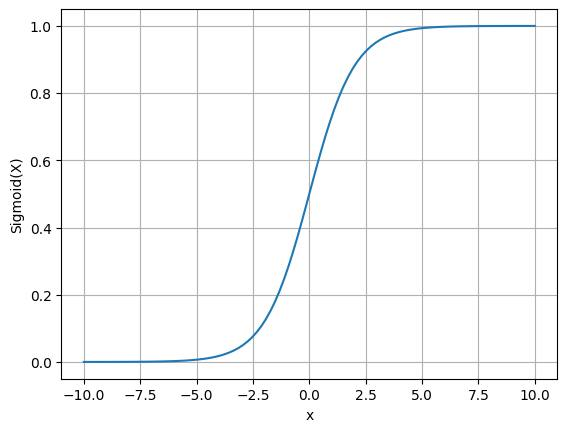


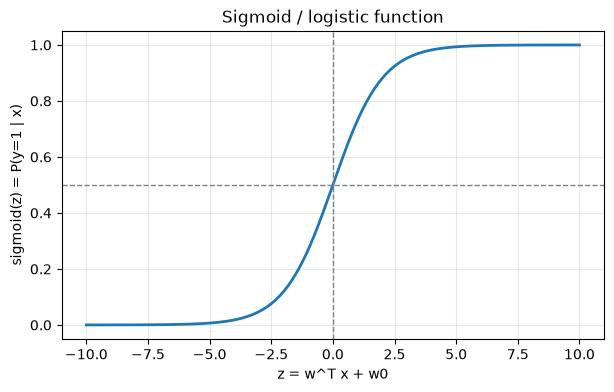

sigmoid(0) = 0.5
sigmoid(6) ≈ 0.9975
sigmoid(-6) ≈ 0.0025


In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 400) # 400 datapoints b/w -10 and 10

plt.figure(figsize=(7, 4))

plt.plot(z, sigmoid(z), lw=2)

plt.axhline(0.5, color='gray', ls='--', lw=1)
plt.axvline(0, color='gray', ls='--', lw=1)
plt.xlabel('z = w^T x + w0')
plt.ylabel('sigmoid(z) = P(y=1 | x)')
plt.title('Sigmoid / logistic function')
plt.grid(True, alpha=0.3)
plt.show()

print('sigmoid(0) =', sigmoid(0))
print('sigmoid(6) ≈', round(sigmoid(6), 4))
print('sigmoid(-6) ≈', round(sigmoid(-6), 4))



# 5. Geometry: distance to the boundary ↔ confidence

$z = w^{\top} x + w_0$ is (up to the scale of $w$) a **signed distance** to the decision boundary $z=0$.

- Far on the positive side → $\sigma(z)$ near 1 (confident class 1)
- Near the boundary → $\sigma(z)$ near 0.5 (uncertain)
- Far on the negative side → $\sigma(z)$ near 0 (confident class 0)


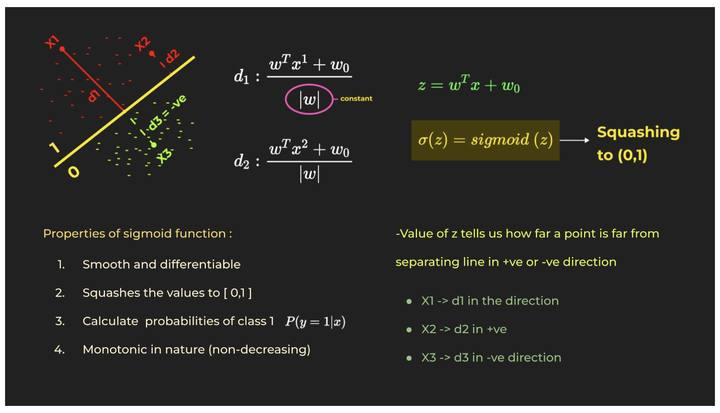


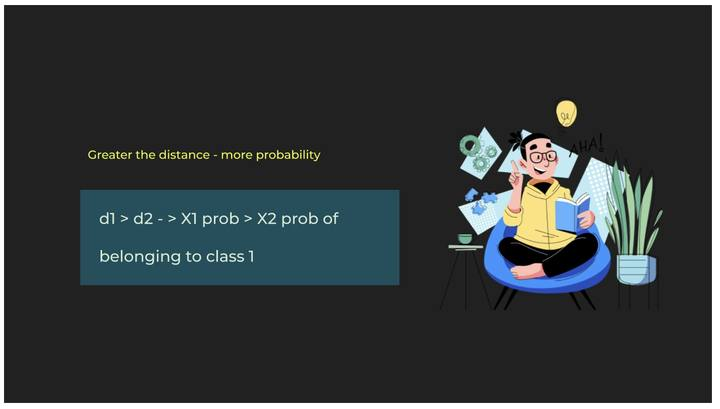


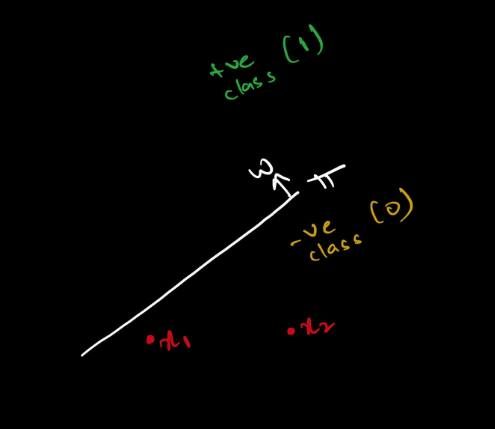


# Quiz 1

**What happens when the input to the sigmoid function is a very large negative value?**

- The output becomes negative
- The output approaches 0
- The output approaches 1
- The output becomes undefined


# Quiz 2

**Which point will have a higher probability of belonging to class 1?** (use the geometric slide with $x_1$ and $x_2$)

- x1
- x2


# 6. Light log-loss (formula only)

We want parameters $w$ so that predicted probabilities match the observed labels.

For one point with true label $y \in \{0,1\}$ and prediction $\hat{p}=\sigma(z)$:

$$
\ell = -\big( y \log \hat{p} + (1-y)\log(1-\hat{p}) \big)
$$

Average over the training set → **log-loss** / binary cross-entropy (negative log-likelihood).

**Why not MSE + sigmoid?** That combination is typically **non-convex** in $w$, so GD can get stuck. Log-loss + sigmoid stays a standard convex setup for linear logistic regression.

We skip Newton / Hessian updates here — use `sklearn`'s solver in practice.


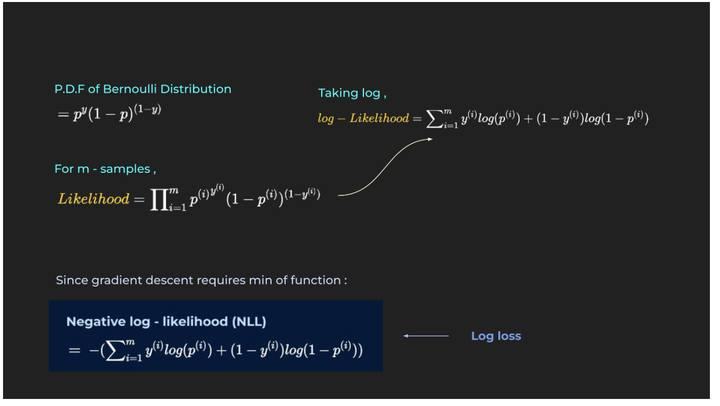


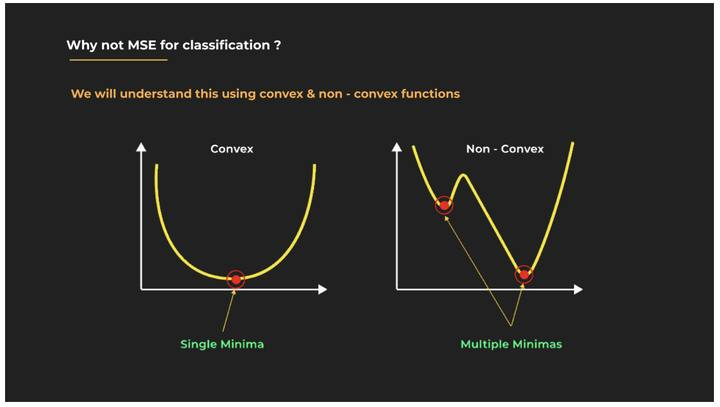


In [ ]:
# Log-loss intuition on single points (y=1)
def log_loss_point(y, p, eps=1e-15):
    p = np.clip(p, eps, 1 - eps)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p))

for p in [0.99, 0.5, 0.1]:
    print(f'y=1, p={p:.2f} -> log_loss={log_loss_point(1, p):.4f}')

print('y=0, p=0.01 ->', round(log_loss_point(0, 0.01), 4), '(confident correct: small loss)')
print('y=0, p=0.99 ->', round(log_loss_point(0, 0.99), 4), '(confident wrong: large loss)')



y=1, p=0.99 -> log_loss=0.0101
y=1, p=0.50 -> log_loss=0.6931
y=1, p=0.10 -> log_loss=2.3026
y=0, p=0.01 -> 0.0101 (confident correct: small loss)
y=0, p=0.99 -> 4.6052 (confident wrong: large loss)


# Quiz 3

**Supposedly your $y = 0$ and $\hat{y} = 0.01$. What is true about the log-loss?**

- log-loss will be a very high value
- log-loss will be a very low value
- log-loss will be 0


# 7. Code: `LogisticRegression` + decision boundary

In this section we will:

1. Build a 2D synthetic binary set (`make_classification`).
2. Fit `StandardScaler` + `LogisticRegression`.
3. Plot points and the linear decision boundary.
4. Peek at `predict_proba` near vs far from the boundary.


In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

np.random.seed(42)
X, y = make_classification(
    n_samples=400,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.2,
    random_state=42,
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000)),
])
clf.fit(X_train, y_train)
print('train acc', round(clf.score(X_train, y_train), 3))
print('test acc ', round(clf.score(X_test, y_test), 3))
print('coef', clf.named_steps['lr'].coef_)
print('intercept', clf.named_steps['lr'].intercept_)



train acc 0.923
test acc  0.86
coef [[0.78462786 3.90302617]]
intercept [-0.50046733]


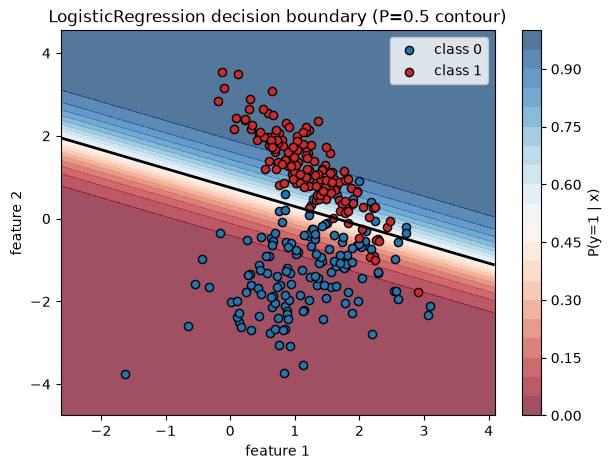

In [ ]:
# Decision boundary in original feature space (after inverse-thinking via mesh + pipeline)
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300),
)
grid = np.c_[xx.ravel(), yy.ravel()]
zz = clf.predict_proba(grid)[:, 1].reshape(xx.shape) # Sigmoid Score

plt.figure(figsize=(7, 5))
cs = plt.contourf(xx, yy, zz, levels=20, cmap='RdBu', alpha=0.7)
plt.colorbar(cs, label='P(y=1 | x)')
plt.contour(xx, yy, zz, levels=[0.5], colors='k', linewidths=2)
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='tab:blue', edgecolor='k', label='class 0', s=35)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='tab:red', edgecolor='k', label='class 1', s=35)
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.title('LogisticRegression decision boundary (P=0.5 contour)')
plt.legend()
plt.show()



# Quiz 4

**In logistic regression, the output of the sigmoid function is interpreted as:**

- Class probabilities
- Raw scores
- Error rates
- Regression coefficients


# 8. Confusion matrix, precision, recall, F1

After thresholding probabilities we get hard predictions. Compare to truth:

|  | Pred 0 | Pred 1 |
|---|---|---|
| **True 0** | TN | FP |
| **True 1** | FN | TP |

Definitions (class 1 = positive):

$$
\mathrm{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN}
$$

$$
\mathrm{Precision} = \frac{TP}{TP+FP} \quad \text{(of predicted positives, how many were right?)}
$$

$$
\mathrm{Recall} = \frac{TP}{TP+FN} \quad \text{(of actual positives, how many did we catch?)}
$$

$$
F_1 = 2 \cdot \frac{\mathrm{precision}\cdot\mathrm{recall}}{\mathrm{precision}+\mathrm{recall}}
$$

**When each metric matters:**

- **Precision** high when false alarms are costly (spam filter: do not bury real mail).
- **Recall** high when misses are costly (disease screening, fraud, churn outreach you cannot miss).
- **F1** balances both when you need a single number and classes may be uneven.
- **Accuracy** is fine when classes are balanced and errors cost about the same; dangerous otherwise (next section).


Confusion matrix:
 [[41  9]
 [ 5 45]]
accuracy  0.86
precision 0.833
recall    0.9
f1        0.865
              precision    recall  f1-score   support

           0      0.891     0.820     0.854        50
           1      0.833     0.900     0.865        50

    accuracy                          0.860       100
   macro avg      0.862     0.860     0.860       100
weighted avg      0.862     0.860     0.860       100



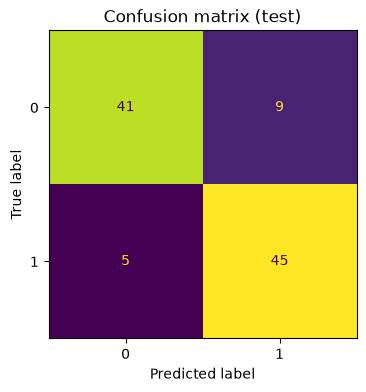

In [ ]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, classification_report, accuracy_score,
)

y_pred = clf.predict(X_test)

#                     True.    Pred.
cm = confusion_matrix(y_test, y_pred)

print('Confusion matrix:\n', cm)
print('accuracy ', round(accuracy_score(y_test, y_pred), 3))
print('precision', round(precision_score(y_test, y_pred), 3))
print('recall   ', round(recall_score(y_test, y_pred), 3))
print('f1       ', round(f1_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred, digits=3))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm, display_labels=['0', '1']).plot(ax=ax, colorbar=False)
plt.title('Confusion matrix (test)')
plt.show()



# Quiz 5

**A hospital model flags patients for a rare disease follow-up. Missing a true case is much worse than an extra false alarm. Which metric should you prioritize first?**

- Precision
- Recall
- Accuracy alone
- Mean squared error


# 9. ROC curve and AUC

Vary the probability threshold from high → low. For each threshold compute:

- **TPR (recall)** = $TP / (TP+FN)$
- **FPR** = $FP / (FP+TN)$

Plot TPR vs FPR → **ROC curve**.

**AUC (Area Under the ROC Curve):**

- 1.0: perfect ranking of positives above negatives
- 0.5: random ranking
- Useful summary of ranking quality across thresholds

ROC/AUC can look optimistic under **severe imbalance** (next: prefer PR curves too).


ROC AUC = 0.965


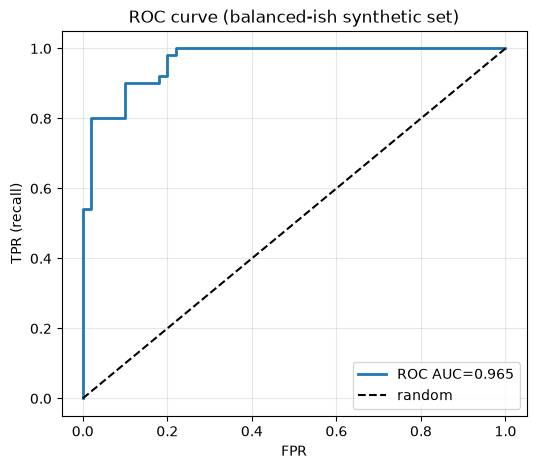

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

y_proba = clf.predict_proba(X_test)[:, 1]
fpr, tpr, thr = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
print('ROC AUC =', round(auc, 3))

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f'ROC AUC={auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='random')
plt.xlabel('FPR')
plt.ylabel('TPR (recall)')
plt.title('ROC curve (balanced-ish synthetic set)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



# 10. Class imbalance and the accuracy trap

Suppose 95% of customers do **not** churn. A dummy model that always predicts "no churn" gets **95% accuracy** and is useless for finding churners.

**Think about it:** Always ask "accuracy of what?" Check class counts, then precision/recall/F1 (and PR curves).

Next we build a **synthetic imbalanced** problem and see how accuracy can mislead.


In [ ]:
# Imbalanced binary classification
Xb, yb = make_classification(
    n_samples=5000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    weights=[0.95, 0.05],  # ~5% positives
    flip_y=0.02,
    random_state=7,
)
print('class counts:', np.bincount(yb), 'positive rate=', round(yb.mean(), 3))

Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(
    Xb, yb, test_size=0.25, random_state=7, stratify=yb
)

# Dummy baseline: always predict majority class 0
dummy_pred = np.zeros_like(yb_te)
print('\nAlways-0 baseline')
print(' accuracy', round(accuracy_score(yb_te, dummy_pred), 3))
print(' precision(pos)', precision_score(yb_te, dummy_pred, zero_division=0))
print(' recall(pos)   ', recall_score(yb_te, dummy_pred, zero_division=0))
print(' f1(pos)       ', f1_score(yb_te, dummy_pred, zero_division=0))

imb_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=2000)),
])
imb_clf.fit(Xb_tr, yb_tr)
pred_default = imb_clf.predict(Xb_te)  # threshold 0.5
print('\nLogReg @ threshold 0.5')
print(' accuracy', round(accuracy_score(yb_te, pred_default), 3))
print(' precision', round(precision_score(yb_te, pred_default, zero_division=0), 3))
print(' recall   ', round(recall_score(yb_te, pred_default, zero_division=0), 3))
print(' f1       ', round(f1_score(yb_te, pred_default, zero_division=0), 3))
print(confusion_matrix(yb_te, pred_default))



class counts: [4705  295] positive rate= 0.059

Always-0 baseline
 accuracy 0.941
 precision(pos) 0.0
 recall(pos)    0.0
 f1(pos)        0.0

LogReg @ threshold 0.5
 accuracy 0.96
 precision 0.929
 recall    0.351
 f1        0.51
[[1174    2]
 [  48   26]]


# Quiz 6

**A dataset has 980 negative and 20 positive examples. A model predicts "negative" for every row. Which statement is true?**

- Accuracy is about 98%, but recall for the positive class is 0
- Accuracy is about 2%, so the model is clearly bad on accuracy alone
- Precision and recall for the positive class must both be near 1
- F1 for the positive class must be near 1 whenever accuracy is high


# 11. Threshold tuning and PR vs ROC

`predict` uses threshold 0.5 by default. On imbalanced data you often **move the operating point**:

- Lower threshold → more predicted positives → **higher recall**, usually **lower precision**
- Higher threshold → fewer predicted positives → **higher precision**, usually **lower recall**

Choose the threshold on **validation** using the business cost of FP vs FN. Do not peek repeatedly at the final test set.

### ROC vs Precision-Recall

| Curve | Axes | When it shines |
|---|---|---|
| ROC | TPR vs FPR | Ranking quality; less misleading when classes are balanced |
| PR | Precision vs Recall | **Imbalanced** positives; focuses on the rare class |

Under imbalance, ROC AUC can stay high while the PR curve (and positive-class F1) look mediocre. Report **both**, and optimize the metric that matches the product goal.


Best F1 operating point on TEST (demo only; use validation in real work):
 thr=0.30 P=0.783 R=0.486 F1=0.600 Acc=0.962


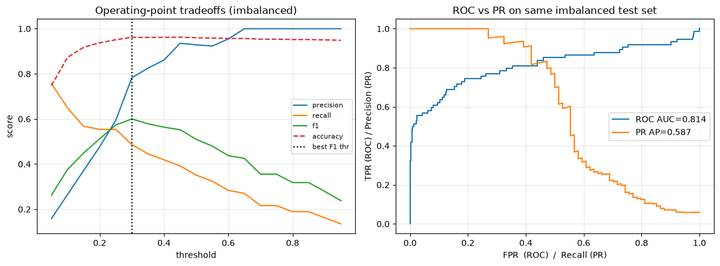

Note: ROC AUC can look healthy while Average Precision (PR) is much lower under imbalance.


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

proba = imb_clf.predict_proba(Xb_te)[:, 1]

# Sweep thresholds: precision / recall / f1 / accuracy
thresholds = np.linspace(0.05, 0.95, 19)
rows = []
for t in thresholds:
    pred = (proba >= t).astype(int)
    rows.append((
        t,
        precision_score(yb_te, pred, zero_division=0),
        recall_score(yb_te, pred, zero_division=0),
        f1_score(yb_te, pred, zero_division=0),
        accuracy_score(yb_te, pred),
    ))
rows = np.array(rows)
best_f1_idx = np.argmax(rows[:, 3])
print('Best F1 operating point on TEST (demo only; use validation in real work):')
print(' thr={:.2f} P={:.3f} R={:.3f} F1={:.3f} Acc={:.3f}'.format(*rows[best_f1_idx]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Metric vs threshold
ax = axes[0]
ax.plot(rows[:, 0], rows[:, 1], label='precision')
ax.plot(rows[:, 0], rows[:, 2], label='recall')
ax.plot(rows[:, 0], rows[:, 3], label='f1')
ax.plot(rows[:, 0], rows[:, 4], label='accuracy', ls='--')
ax.axvline(rows[best_f1_idx, 0], color='k', ls=':', label='best F1 thr')
ax.set_xlabel('threshold')
ax.set_ylabel('score')
ax.set_title('Operating-point tradeoffs (imbalanced)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ROC vs PR
fpr, tpr, _ = roc_curve(yb_te, proba)
prec, rec, _ = precision_recall_curve(yb_te, proba)
roc_auc = roc_auc_score(yb_te, proba)
ap = average_precision_score(yb_te, proba)

ax = axes[1]
ax.plot(fpr, tpr, label=f'ROC AUC={roc_auc:.3f}')
ax.plot(rec, prec, label=f'PR AP={ap:.3f}')
ax.set_xlabel('FPR  (ROC)  /  Recall (PR)')
ax.set_ylabel('TPR (ROC) / Precision (PR)')
ax.set_title('ROC vs PR on same imbalanced test set')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Note: ROC AUC can look healthy while Average Precision (PR) is much lower under imbalance.')



# Quiz 7

**You have a highly imbalanced fraud dataset (~1% fraud). Which practice is most appropriate?**

- Report accuracy only; if it is above 99% the model is solved
- Prefer Precision-Recall curves / positive-class F1, and tune the decision threshold on validation
- Always keep the probability threshold fixed at 0.5 no matter the costs
- Use ROC AUC alone and ignore precision on the fraud class


# Wrap-up

1. Logistic regression: linear score $z=w^{\top}x+w_0$, sigmoid → probability, threshold → class.
2. Geometry: distance to the separating hyperplane drives confidence.
3. Train with log-loss (not MSE+sigmoid); in practice use `sklearn.linear_model.LogisticRegression`.
4. Confusion matrix → precision / recall / F1; pick metrics from error costs.
5. ROC AUC summarizes ranking across thresholds; still check PR under imbalance.
6. Accuracy can look great while missing the rare class; tune the operating point on validation.
